# Long logic sentences and FOL error suite — `data.py` demo

This notebook runs the artifact's `data.py`, split into cells with explanations. The artifact is a
**meta-evaluation dataset for NL→FOL faithfulness metrics**. It has two held-out tables:

* **PERTURB** (`perturb_suite`): typed mutants of trusted reference formulas. The operators are NEG, REV, QUANT, RESTR, CONN,
  MOVE, DROP, ADD, SWAP, BIND and MEANING_RENAME, each applied at a DOWN or UP monotonicity position. Every mutant is labelled `ERROR`.
  The table also holds meaning-preserving controls (RENAME, REORDER, CONTRAPOSITIVE/DEMORGAN), which are labelled `CORRECT`.
  Every mutant is z3 non-equivalent to the accepted readings, and every control is z3-equivalent to them.
* **R_COMP** (`rcomp_sentences`): long templated sentences (≥25 words, ≥3 conditions, one unless/except/provided-that/only-if
  clause). Their *weak* and *strong* reference readings come from the template. The sentences are built from an atom lexicon
  mined from verified FOLIO/MALLS references.

`data.py` does not generate anything new. It takes the rows built by the pipeline (`work/assembled.json`) and **re-verifies every row
against its public sources**. For each row it writes `metadata_source_verified`, `metadata_source_file` and `metadata_verify_notes`:

| group | check |
|---|---|
| `rcomp_sentences` | every lexicon entry traces to a FOLIO-v2-train premise + folio-refined formula, or to a dataset-E heldout row (+ MALLS-v0.1 train); the composed text is not in the screen-exclusion hash set; `reference_fol == reference_fol_weak` |
| `perturb_suite` | the base text + formula equal the dataset-E heldout row (and its FOLIO/MALLS origin), or equal the R_COMP weak reading; the recomputed `item_id` recipe matches |
| `adjudicator_check` | the QA item exists in `perturb_suite` with the same candidate and the same known label |

**Demo scale.** `mini_demo_data.json` holds a curated subset of 84 rows: 15 R_COMP sentences (the bases of the QA items, every template T1–T9,
and a reserve sentence), 57 PERTURB rows (one per operator × polarity × base kind, plus controls) and 12 adjudicator QA items. It also holds exactly the
source records needed to verify those rows. The screen-exclusion sources are **small random samples**, because the full set is about 2 MB.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# matplotlib (visualisation only) — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

## Imports

This is the original import block of `data.py`. The only addition is matplotlib, for the summary plot at the end. The logger setup
is also kept from the original. The one change: the file sink (`logs/data.log`) is commented out, so the notebook writes no log directory.

In [2]:
from __future__ import annotations

import csv
import hashlib
import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

from loguru import logger

import matplotlib.pyplot as plt

ROOT = Path.cwd()  # notebook: outputs go next to the notebook (original: Path(__file__).resolve().parent)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")  # original file sink, disabled in the demo

1

## Load the demo data (GitHub URL with local fallback)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-2/dataset-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: len(v) if hasattr(v, '__len__') else v for k, v in data["sources"].items()})
print(data["metadata"]["demo_groups"])

{'folio_v2_train': 140, 'folio_refined_train': 140, 'malls_v0.1_train': 44, 'E_heldout': 1, 'exclusion': 8}
{'rcomp_sentences': 15, 'perturb_suite': 57, 'adjudicator_check': 12}


## Config

`data.py` has no training parameters. The only size knob is how many rows of each group get verified.
`MAX_ROWS_PER_GROUP = None` verifies every row in the demo subset. The original run verified all rows of the full dataset:
350 R_COMP sentences, 5,102 PERTURB rows and 60 QA rows, against the full source files.
If you set a small cap, some `adjudicator_check` rows can fail verification. This happens when the `perturb_suite` row they point to was cut off by the cap.

In [5]:
MAX_ROWS_PER_GROUP = None      # None = all demo rows (original: all 350 + 5,102 + 60 rows of the full dataset)
N_UNVERIFIED_TO_SHOW = 10      # original: bad[:10]
SIZE_WARN_BYTES = 30e6         # original: warn if full_data_out.json > 30 MB

## Helpers: text normalisation and hashing

These are exact copies of dataset E's `select_sentences.py` helpers. `norm` lowercases the text and strips punctuation.
`h` is the SHA-1 of the normalised text, which is used for the screen-exclusion set. `fsq` removes whitespace, so two formulas can be compared.

In [6]:
# ---- exact copies of dataset E's src_e/select_sentences.py helpers (kept standalone so data.py needs no z3)
def norm(s: str) -> str:
    s = s.lower().replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def h(s: str) -> str:
    return hashlib.sha1(norm(s).encode()).hexdigest()


def split_sents(block: str) -> list[str]:
    return [p.strip() for p in re.split(r"(?<=[.!?])\s+|\n+", block) if p.strip()]


def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]


def fsq(f: str) -> str:
    """Formula comparison key: whitespace removed."""
    return re.sub(r"\s+", "", f or "")

## Load the sources and build the lookup tables

`load_sources` builds these lookup tables:
* `folio_train_premises`: the set of normalised FOLIO-v2 train premises.
* `refined`: normalised premise → set of folio-refined FOL formulas. A row is used only when its NL premises and FOL premises line up one to one.
* `malls_train`: normalised MALLS-v0.1 train NL → set of FOL formulas.
* `exclusion`: SHA-1 hashes of every sentence in the held-out and test sources (FOLIO validation, folio-refined validation,
  the curated DSAVlab sets, MALLS test and Logic-LM dev outputs). A composed R_COMP sentence must not collide with any of them.
* `E_by_sid` / `E_by_text`: dataset E's heldout sentences, with their trust status (TRUSTED_AGREED, GOLD_PANEL_OK or PANEL_REPAIRED).

**Change from the original:** each `open(T / file)` / `jl(T / file)` read is replaced by the matching list in `data["sources"]`.
The logic is otherwise unchanged.

In [7]:
SRC = data["sources"]  # demo: replaces T = ROOT / "temp" / "datasets"
EX = SRC["exclusion"]


def load_sources() -> dict:
    S = {}
    S["folio_train_premises"] = set()
    for r in SRC["folio_v2_train"]:  # jl(T / "tasksource__folio" / "folio_v2_train.jsonl")
        for p in r["premises"].split("\n"):
            if p.strip():
                S["folio_train_premises"].add(norm(p))
    refined = defaultdict(set)
    for r in SRC["folio_refined_train"]:  # csv.DictReader(open(T / "yfxiao__folio-refined__train.csv"))
        nls = [x for x in r["nl premises"].split("\n") if x.strip()]
        fols = [x for x in r["fol premises"].split("\n") if x.strip()]
        if len(nls) == len(fols):
            for n, f in zip(nls, fols):
                refined[norm(n)].add(fsq(f))
    S["refined"] = refined
    malls = defaultdict(set)
    for r in SRC["malls_v0.1_train"]:  # json.loads((T / "yuan-yang__MALLS-v0__MALLS-v0.1-train.json").read_text())
        malls[norm(r["NL"])].add(fsq(r["FOL"]))
    S["malls_train"] = malls
    ex = set()

    def add(s):
        for x in [s] + split_sents(s):
            if x.strip():
                ex.add(h(x))
    for r in EX["folio_v2_validation"]:  # jl(T / "tasksource__folio" / "folio_v2_validation.jsonl")
        for p in r["premises"].split("\n"):
            add(p)
        add(r["conclusion"])
    for r in EX["folio_refined_validation"]:  # csv.DictReader(open(T / "yfxiao__folio-refined__validation.csv"))
        for p in r["nl premises"].split("\n"):
            add(p)
        add(r["nl conclusion"])
    for f in ("DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances",
              "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances"):
        for r in EX[f]:  # jl(T / f)
            add(r["NL_sentence"])
    for r in EX["MALLS-v0.1-test"]:  # json.loads((T / "yuan-yang__MALLS-v0__MALLS-v0.1-test.json").read_text())
        add(r["NL"])
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in EX[f"logiclm_FOLIO_dev_{m}"]:  # json.loads((T / "logiclm_FOLIO_dev_outputs" / f"FOLIO_dev_{m}.json").read_text())
            add(r["context"])
            add(r["question"].split("?", 1)[-1])
    S["exclusion"] = ex
    e = SRC["E_heldout"]  # json.loads((T / "E_heldout_dataset1_full_data_out.json").read_text())
    hs = [g for g in e["datasets"] if g["dataset"] == "heldout_sentences"][0]["examples"]
    S["E_by_sid"] = {x["metadata_sentence_id"]: {**json.loads(x["input"]), "status": x["output"],
                                                 "orig": x.get("metadata_original_reference_fol")} for x in hs}
    S["E_by_text"] = defaultdict(list)
    for sid, x in S["E_by_sid"].items():
        S["E_by_text"][norm(x["text"])].append(x)
    logger.info(f"sources: {len(S['folio_train_premises'])} FOLIO-v2 train premises, {len(refined)} refined premises, "
                f"{len(malls)} MALLS-train texts, {len(ex)} exclusion hashes, {len(hs)} E heldout sentences")
    return S

## Tracing a lexicon entry to its source

Each atom in the R_COMP lexicon (for example `Surprise(x)`) was mined from one verified reference sentence. An entry passes when
the predicate occurs in its source formula **and** the (text, formula) pair can be found in the stated source:
* `FOLIO-v2-train_agreed`: the text is a FOLIO-v2 train premise, and folio-refined gives the same formula.
* `E_heldout_*`: the text and formula match a dataset-E heldout row with that status. A GOLD_PANEL_OK row must also match a MALLS-v0.1 train
  record, and a TRUSTED_AGREED row must also match FOLIO.

In [8]:
def verify_lexicon_entry(e: dict, S: dict) -> tuple[bool, str, str]:
    n, f = norm(e["source_text"]), fsq(e["source_fol"])
    pred = e["pred"]
    if not re.search(r"(?<![A-Za-z0-9_])" + re.escape(pred) + r"\(", e["source_fol"]):
        return False, "", f"atom {pred} not in source formula"
    if e["source"] == "FOLIO-v2-train_agreed":
        ok = n in S["folio_train_premises"] and f in S["refined"].get(n, set())
        return ok, "tasksource__folio/folio_v2_train.jsonl + yfxiao__folio-refined__train.csv", "" if ok else "FOLIO source mismatch"
    if e["source"].startswith("E_heldout_"):
        rows = [x for x in S["E_by_text"].get(n, []) if fsq(x["reference_fol"]) == f]
        ok = bool(rows) and rows[0]["status"] == e["source"].replace("E_heldout_", "")
        src = "E_heldout_dataset1_full_data_out.json"
        if ok and rows[0]["status"] == "GOLD_PANEL_OK":
            ok = f in S["malls_train"].get(n, set())
            src += " + yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
        elif ok and rows[0]["status"] == "TRUSTED_AGREED":
            ok = n in S["folio_train_premises"] and f in S["refined"].get(n, set())
            src += " + tasksource__folio + yfxiao__folio-refined"
        return ok, src, "" if ok else "E source mismatch"
    return False, "", f"unknown source {e['source']}"

## `main()` step 1: load the assembled groups, the sources and the lexicon

From here on, the body of the original `main()` runs as top-level cells, one step per cell, with the same code.
`A` (originally `work/assembled.json`) and the lexicon (originally `lexicon.json`) come from `data`.

In [9]:
A = data["assembled"]  # json.loads((ROOT / "work" / "assembled.json").read_text())
S = load_sources()
lex = {x["lexicon_id"]: x for x in data["lexicon"]["entries"]}  # json.loads((ROOT / "lexicon.json").read_text())["entries"]
lex_ver = {lid: verify_lexicon_entry(x, S) for lid, x in lex.items()}
logger.info(f"lexicon entries traced to source: {sum(v[0] for v in lex_ver.values())}/{len(lex_ver)}")
G = {g["dataset"]: g["examples"][:MAX_ROWS_PER_GROUP] for g in A["datasets"]}  # demo: optional row cap
stats = Counter()

12:48:28|INFO   |sources: 227 FOLIO-v2 train premises, 227 refined premises, 44 MALLS-train texts, 255 exclusion hashes, 50 E heldout sentences


12:48:28|INFO   |lexicon entries traced to source: 81/81


## Step 2: verify `rcomp_sentences`

A long composed sentence is verified when (a) every lexicon entry it uses traces to its source, (b) its text does not collide with
the screen-exclusion hashes, and (c) its `reference_fol` equals the **weak** exception reading. The weak reading is the one used as the base for PERTURB.

In [10]:
# ---- rcomp_sentences
rc_weak = {}
for e in G["rcomp_sentences"]:
    inp = json.loads(e["input"])
    rc_weak[e["metadata_sentence_id"]] = inp["reference_fol_weak"]
    notes = [f"{lid}: {lex_ver[lid][2]}" for lid in e["metadata_lexicon_ids"] if not lex_ver[lid][0]]
    if h(inp["text"]) in S["exclusion"]:
        notes.append("screen hash collision")
    if inp["reference_fol"] != inp["reference_fol_weak"]:
        notes.append("reference_fol != weak reading")
    e["metadata_source_verified"] = not notes
    e["metadata_source_file"] = "; ".join(sorted({lex_ver[lid][1] for lid in e["metadata_lexicon_ids"] if lex_ver[lid][1]}))
    e["metadata_verify_notes"] = notes
    stats[f"rcomp_sentences_verified_{not notes}"] += 1
print(dict(stats))

{'rcomp_sentences_verified_True': 15}


## Step 3: verify `perturb_suite`

For every mutant or control, the script recomputes `item_id = sha1(system | norm(text) | candidate_fol)[:16]` and checks the
**base** it was derived from. An R_COMP base must equal that sentence's weak reading. A dataset-E base must equal the E heldout row,
and through that row it must equal FOLIO-v2 + folio-refined (TRUSTED_AGREED), a MALLS-v0.1 train record (GOLD_PANEL_OK), or
the MALLS text with E's original gold (PANEL_REPAIRED). For PANEL_REPAIRED, the reference formula is E's repaired one.

In [11]:
# ---- perturb_suite
pert_ids = {}
for e in G["perturb_suite"]:
    inp = json.loads(e["input"])
    notes = []
    if hashlib.sha1((inp["system"] + "|" + norm(inp["text"]) + "|" + inp["candidate_fol"]).encode()).hexdigest()[:16] != e["metadata_item_id"]:
        notes.append("item_id recipe mismatch")
    src = e["metadata_base_source"]
    n, f = norm(inp["text"]), fsq(inp["reference_fol"])
    if src == "RCOMP":
        if fsq(rc_weak.get(e["metadata_sentence_id"], "")) != f:
            notes.append("R_COMP base != weak reading")
        sf = "rcomp_sentences (this dataset)"
    else:
        er = S["E_by_sid"].get(e["metadata_sentence_id"])
        sf = "E_heldout_dataset1_full_data_out.json"
        if er is None or norm(er["text"]) != n or fsq(er["reference_fol"]) != f or "E_" + er["status"] != src:
            notes.append("E base mismatch")
        elif src == "E_TRUSTED_AGREED":
            sf += " + tasksource__folio + yfxiao__folio-refined"
            if not (n in S["folio_train_premises"] and f in S["refined"].get(n, set())):
                notes.append("FOLIO source mismatch")
        elif src == "E_GOLD_PANEL_OK":
            sf += " + yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
            if f not in S["malls_train"].get(n, set()):
                notes.append("MALLS source mismatch")
        elif src == "E_PANEL_REPAIRED":
            sf += " (repaired formula) + yuan-yang__MALLS-v0__MALLS-v0.1-train.json (text)"
            if n not in S["malls_train"] or fsq(er["orig"] or "") not in S["malls_train"][n]:
                notes.append("MALLS text/original-gold mismatch")
    e["metadata_source_verified"] = not notes
    e["metadata_source_file"] = sf
    e["metadata_verify_notes"] = notes
    pert_ids[e["metadata_item_id"]] = (inp["candidate_fol"], e["output"])
    stats[f"perturb_verified_{not notes}"] += 1
print(dict(stats))

{'rcomp_sentences_verified_True': 15, 'perturb_verified_True': 57}


## Step 4: verify `adjudicator_check` and the pending `rcomp_candidates`

The 60 adjudicator QA items (12 in the demo) are known-label PERTURB items used to test the LLM adjudicator. Each one must point to
a `perturb_suite` row with the same candidate formula and the same label.

`rcomp_candidates` is the set of real system outputs on R_COMP sentences. It is **still pending**, because the OpenRouter key ran out
before generation, so it is absent here and the branch below is skipped. Once it exists, it is checked against `raw/generations.jsonl`.

In [12]:
# ---- adjudicator_check
for e in G["adjudicator_check"]:
    inp = json.loads(e["input"])
    p = pert_ids.get(e["metadata_item_id"])
    ok = p is not None and p[0] == inp["candidate_fol"] and p[1] == e["output"]
    e["metadata_source_verified"] = ok
    e["metadata_source_file"] = "perturb_suite (this dataset)"
    e["metadata_verify_notes"] = [] if ok else ["not found in perturb_suite with the same candidate/label"]
    stats[f"adjudicator_check_verified_{ok}"] += 1
# ---- rcomp_candidates (present once generation has run)
if "rcomp_candidates" in G:
    last = {}
    for r in jl(ROOT / "raw" / "generations.jsonl"):
        last[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
    for e in G["rcomp_candidates"]:
        inp = json.loads(e["input"])
        r = last.get((e["metadata_sentence_id"], e["metadata_slot"], e["metadata_prompt_variant"]))
        ok = r is not None and (r.get("raw_output") or "") == (e["metadata_raw_output"] or "")
        e["metadata_source_verified"] = ok
        e["metadata_source_file"] = "raw/generations.jsonl"
        e["metadata_verify_notes"] = [] if ok else ["raw_output mismatch"]
        stats[f"rcomp_candidates_verified_{ok}"] += 1
print(dict(stats))

{'rcomp_sentences_verified_True': 15, 'perturb_verified_True': 57, 'adjudicator_check_verified_True': 12}


## Step 5: write `full_data_out.json` and `adjudicator_check_out.json`

The output is in the aii `exp_sel_data_out` format: `{metadata, datasets: [{dataset, examples}]}`. It holds the two chosen datasets,
R_COMP and PERTURB. The adjudicator QA table goes to a separate auxiliary file. In the demo, both files are written next to the
notebook and contain only the demo subset.

In [13]:
# The two chosen datasets: R_COMP (rcomp_candidates once generated + rcomp_sentences) and PERTURB (perturb_suite).
# adjudicator_check (60 known-label QA rows) is an auxiliary label-quality table -> adjudicator_check_out.json.
order = ["rcomp_candidates", "rcomp_sentences", "perturb_suite"]
groups = [{"dataset": k, "examples": G[k]} for k in order if k in G]
meta = dict(A["metadata"])
meta["groups"] = {g["dataset"]: len(g["examples"]) for g in groups}
meta["datasets_chosen"] = {"R_COMP": [k for k in ("rcomp_candidates", "rcomp_sentences") if k in G],
                           "PERTURB": ["perturb_suite"]}
meta["auxiliary_file"] = "adjudicator_check_out.json (60 known-label adjudicator QA rows, same row format)"
meta["source_verification"] = dict(stats)
(ROOT / "full_data_out.json").write_text(json.dumps({"metadata": meta, "datasets": groups}, ensure_ascii=False, indent=1))
aux = {"metadata": {"description": "adjudicator known-label check items (STEP 8a) on R_COMP bases",
                    "source_verification": {k: v for k, v in stats.items() if k.startswith("adjudicator")}},
       "datasets": [{"dataset": "adjudicator_check", "examples": G["adjudicator_check"]}]}
(ROOT / "adjudicator_check_out.json").write_text(json.dumps(aux, ensure_ascii=False, indent=1))
size = (ROOT / "full_data_out.json").stat().st_size
logger.info(f"full_data_out.json {size / 1e6:.1f} MB; groups {({g['dataset']: len(g['examples']) for g in groups})}; "
            f"verification {dict(stats)}")
bad = [e for g in groups for e in g["examples"] if not e["metadata_source_verified"]]
for e in bad[:N_UNVERIFIED_TO_SHOW]:
    logger.warning(f"unverified {e.get('metadata_item_id') or e.get('metadata_sentence_id')}: {e['metadata_verify_notes']}")
if size > SIZE_WARN_BYTES:
    logger.warning("full_data_out.json exceeds 30 MB: split with aii-file-size-limit")

12:48:28|INFO   |full_data_out.json 0.2 MB; groups {'rcomp_sentences': 15, 'perturb_suite': 57}; verification {'rcomp_sentences_verified_True': 15, 'perturb_verified_True': 57, 'adjudicator_check_verified_True': 12}


## Results: what the verified dataset looks like

The cells below summarise the verification outcome and show the structure of the two tables:
* the verification counts per group,
* one PERTURB example (a base formula, its mutant and the error type),
* PERTURB rows by operator and polarity, plus the meaning-preserving controls,
* R_COMP sentence complexity (words, conditions, nesting depth) by template, with a weak vs strong reading.

In [14]:
print("Source verification:", dict(stats))
print(f"lexicon entries traced: {sum(v[0] for v in lex_ver.values())}/{len(lex_ver)}")
print(f"unverified rows: {len(bad)}\n")

# one PERTURB example: base (reference) vs typed mutant
ex = next((e for e in G["perturb_suite"] if e["metadata_fold"] == "PERTURB" and e["metadata_operator"] == "NEG"), G["perturb_suite"][0])
inp = json.loads(ex["input"])
print("TEXT      :", inp["text"])
print("REFERENCE :", inp["reference_fol"])
print("CANDIDATE :", inp["candidate_fol"])
print("LABEL     :", ex["output"], "| system", ex["metadata_system"], "| subtype", ex["metadata_subtype"],
      "| polarity", ex.get("metadata_position_polarity"), "| base", ex["metadata_base_source"])

# PERTURB table: rows per operator x polarity
print(f"\n{'operator / control':<24}{'DOWN':>6}{'UP':>6}{'CTRL':>6}  label")
tab = defaultdict(Counter)
for e in G["perturb_suite"]:
    if e["metadata_fold"] == "PERTURB":
        tab[e["metadata_operator"]][e["metadata_position_polarity"]] += 1
    else:
        tab["CTRL:" + e["metadata_subtype"]]["CTRL"] += 1
for k in sorted(tab):
    print(f"{k:<24}{tab[k]['DOWN']:>6}{tab[k]['UP']:>6}{tab[k]['CTRL']:>6}  {'CORRECT' if k.startswith('CTRL') else 'ERROR'}")

# R_COMP sentences: complexity strata
print(f"\n{'sid':<14}{'tmpl':<6}{'clause':<14}{'words':>6}{'conds':>6}{'depth':>6}  verified")
for e in G["rcomp_sentences"]:
    s = e["metadata_strata"]
    print(f"{e['metadata_sentence_id']:<14}{e['metadata_template_id']:<6}{str(s['exception_type']):<14}{s['words']:>6}"
          f"{s['n_conditions']:>6}{s['depth']:>6}  {e['metadata_source_verified']}")
r = json.loads(G["rcomp_sentences"][0]["input"])
print("\nR_COMP TEXT :", r["text"])
print("WEAK        :", r["reference_fol_weak"])
print("STRONG      :", r["reference_fol_strong"])

Source verification: {'rcomp_sentences_verified_True': 15, 'perturb_verified_True': 57, 'adjudicator_check_verified_True': 12}
lexicon entries traced: 81/81
unverified rows: 0

TEXT      : Artists who work in various mediums, possess a unique style, and have a strong portfolio often achieve recognition in the art world.
REFERENCE : ∀x ((Artist(x) ∧ WorkInVariousMediums(x) ∧ Possess(x, uniqueStyle) ∧ Have(x, strongPortfolio)) → OftenAchieve(x, recognition, artWorld))
CANDIDATE : ∀x (¬(Artist(x) ∧ WorkInVariousMediums(x) ∧ Possess(x, uniqueStyle)) ∧ Have(x, strongPortfolio) → OftenAchieve(x, recognition, artWorld))
LABEL     : ERROR | system PERTURB:NEG:DOWN | subtype NEG_INSERT | polarity DOWN | base E_PANEL_REPAIRED

operator / control        DOWN    UP  CTRL  label
ADD                          2     4     0  ERROR
BIND                         3     3     0  ERROR
CONN                         2     3     0  ERROR
CTRL:CONTRAPOSITIVE          0     0     4  CORRECT
CTRL:DEMORGAN        

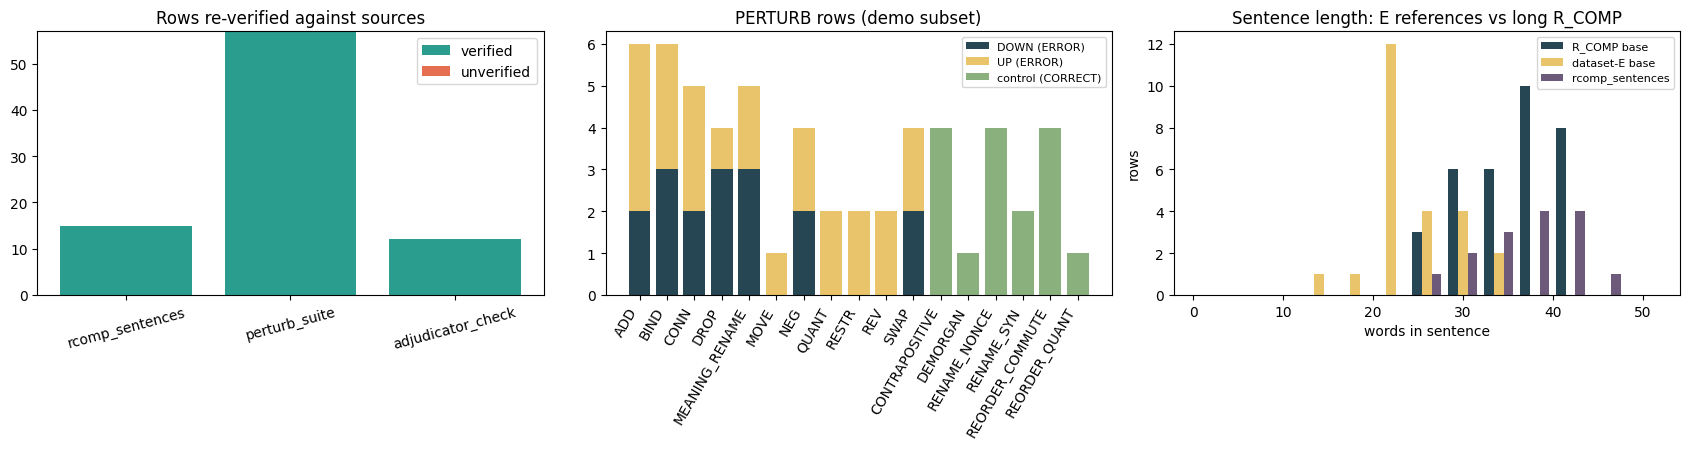

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) verification outcome per group
grp = ["rcomp_sentences", "perturb_suite", "adjudicator_check"]
okc = [sum(e["metadata_source_verified"] for e in G[g]) for g in grp]
badc = [len(G[g]) - o for g, o in zip(grp, okc)]
axes[0].bar(grp, okc, color="#2a9d8f", label="verified")
axes[0].bar(grp, badc, bottom=okc, color="#e76f51", label="unverified")
axes[0].set_title("Rows re-verified against sources"); axes[0].legend(); axes[0].tick_params(axis="x", rotation=15)

# (b) PERTURB rows by operator and polarity (stacked), controls separately
ops = sorted(k for k in tab if not k.startswith("CTRL"))
ctrls = sorted(k for k in tab if k.startswith("CTRL"))
down = [tab[k]["DOWN"] for k in ops]
up = [tab[k]["UP"] for k in ops]
axes[1].bar(ops, down, color="#264653", label="DOWN (ERROR)")
axes[1].bar(ops, up, bottom=down, color="#e9c46a", label="UP (ERROR)")
axes[1].bar([c.replace("CTRL:", "") for c in ctrls], [tab[c]["CTRL"] for c in ctrls], color="#8ab17d", label="control (CORRECT)")
axes[1].set_title("PERTURB rows (demo subset)"); axes[1].legend(fontsize=8); plt.setp(axes[1].get_xticklabels(), rotation=60, ha="right")

# (c) sentence length of the PERTURB bases: short dataset-E references vs long R_COMP sentences
wl = defaultdict(list)
for e in G["perturb_suite"]:
    wl["R_COMP base" if e["metadata_base_source"] == "RCOMP" else "dataset-E base"].append(e["metadata_strata"]["words"])
wl["rcomp_sentences"] = [e["metadata_strata"]["words"] for e in G["rcomp_sentences"]]
axes[2].hist(list(wl.values()), bins=range(0, 56, 4), label=list(wl.keys()), color=["#264653", "#e9c46a", "#6d597a"][:len(wl)])
axes[2].set_xlabel("words in sentence"); axes[2].set_ylabel("rows"); axes[2].legend(fontsize=8)
axes[2].set_title("Sentence length: E references vs long R_COMP")
plt.tight_layout(); plt.show()